# Data import
Just about reading the CSV and looking at basic facts. I'm aware of the risks that come with CSV; I know that floats tend to uh get truncated or rounded. The guess column serves no purpose, and neither does the count one. 
I'm however surprised to see no nulls in the hops and latency attributes. 

In [41]:
from pathlib import Path 
import pandas as pd 

measurements = pd.read_csv(
    Path("output.3.csv"), 
    skip_blank_lines=True, 
    header=0)

measurements["latency"] = pd.to_numeric(measurements.latency, errors='coerce')
measurements["hops"] = pd.to_numeric(measurements.hops, errors='coerce')
measurements.info()

<class 'pandas.DataFrame'>
RangeIndex: 10896 entries, 0 to 10895
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10896 non-null  int64  
 1   origin        10896 non-null  str    
 2   ground_truth  10896 non-null  str    
 3   guess         0 non-null      float64
 4   ip_v4         10896 non-null  str    
 5   ip_v6         1610 non-null   str    
 6   latency       10896 non-null  float64
 7   hops          10896 non-null  float64
 8   count         10896 non-null  int64  
 9   date_time     10896 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 851.4 KB


There appear to be many outliers. This means we will have to avoid standardising our dataset, as this might destroy the properties of our features. Indeed, this simply means the measurements' distribution is non gaussian and normalisation is a better alternative. Furthermore, there is a clear left tail on both the latency and the number of hops.  

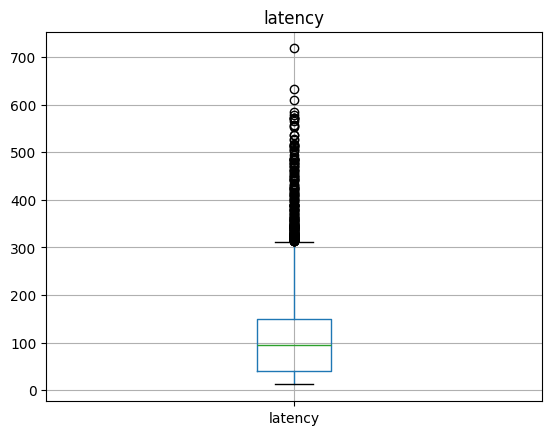

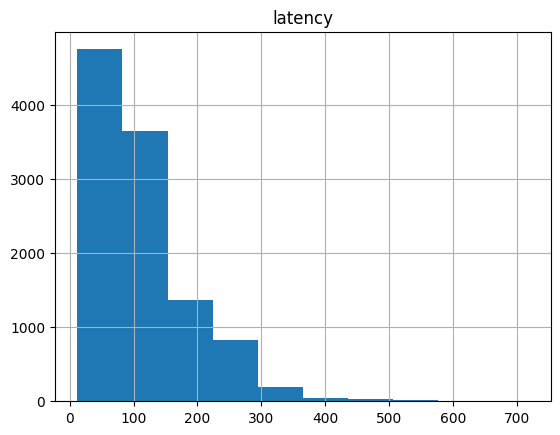

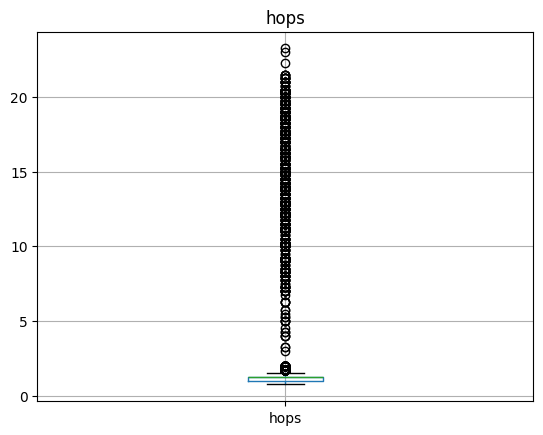

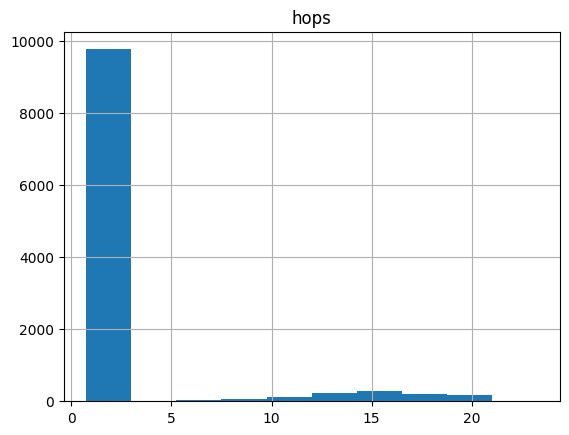

In [42]:
import matplotlib.pyplot as plt

for column in ["latency", "hops"]:
    plt.figure()
    plt.gca().set_title(column)
    measurements.boxplot(column=[column])
    measurements.hist(column=[column])

One can notice above that some country names are in uppercase, whilst some others are in lowercase. Transforming this all in uppercase would be better.  

In [43]:
counts = measurements.groupby(['origin', 'ground_truth']).size().reset_index(name='count')
counts.sort_values('count', ascending=False, inplace=True)
counts.head(30)

,origin,ground_truth,count
180,NordVPN,US,3342
93,NordVPN,GB,1143
73,NordVPN,CA,514
81,NordVPN,DE,439
92,NordVPN,FR,412
58,NordVPN,AU,295
145,NordVPN,NL,291
115,NordVPN,JP,284
111,NordVPN,IT,206
48,Mullvad,us,203


In [44]:
from pandas import DataFrame
from sklearn.compose import ColumnTransformer
import sklearn
from sklearn.preprocessing import FunctionTransformer

# to render all estimators as interactive diagrams
sklearn.set_config(display="diagram")

def upper_series(X):
    # X is a DataFrame with one column
    return X.iloc[:,0].str.upper().to_frame()

preprocessing = ColumnTransformer([
    ("upperisation", FunctionTransformer(upper_series), ["ground_truth"])
], remainder='passthrough')

measurements.values[:] = preprocessing.fit_transform(measurements)

counts = measurements.groupby(['origin', 'ground_truth']).size().reset_index(name='count')
counts.sort_values('count', ascending=False, inplace=True)

counts.head(30)

,origin,ground_truth,count
180,NordVPN,US,3342
93,NordVPN,GB,1143
73,NordVPN,CA,514
81,NordVPN,DE,439
92,NordVPN,FR,412
58,NordVPN,AU,295
145,NordVPN,NL,291
115,NordVPN,JP,284
111,NordVPN,IT,206
48,Mullvad,us,203


Fundamentally, the data we have collected comes from two sources:
1) the RIPE network, that allows measurements 
2) two major VPN providers, that freely provide a list of their servers online

The first source would be used as training and dev set, whilst the second as the final test set. 
Because we are dealing with two very different data sources, questions regarding the distribution of classes come into play. Hence the need to take a look at the different distributions of both sources.

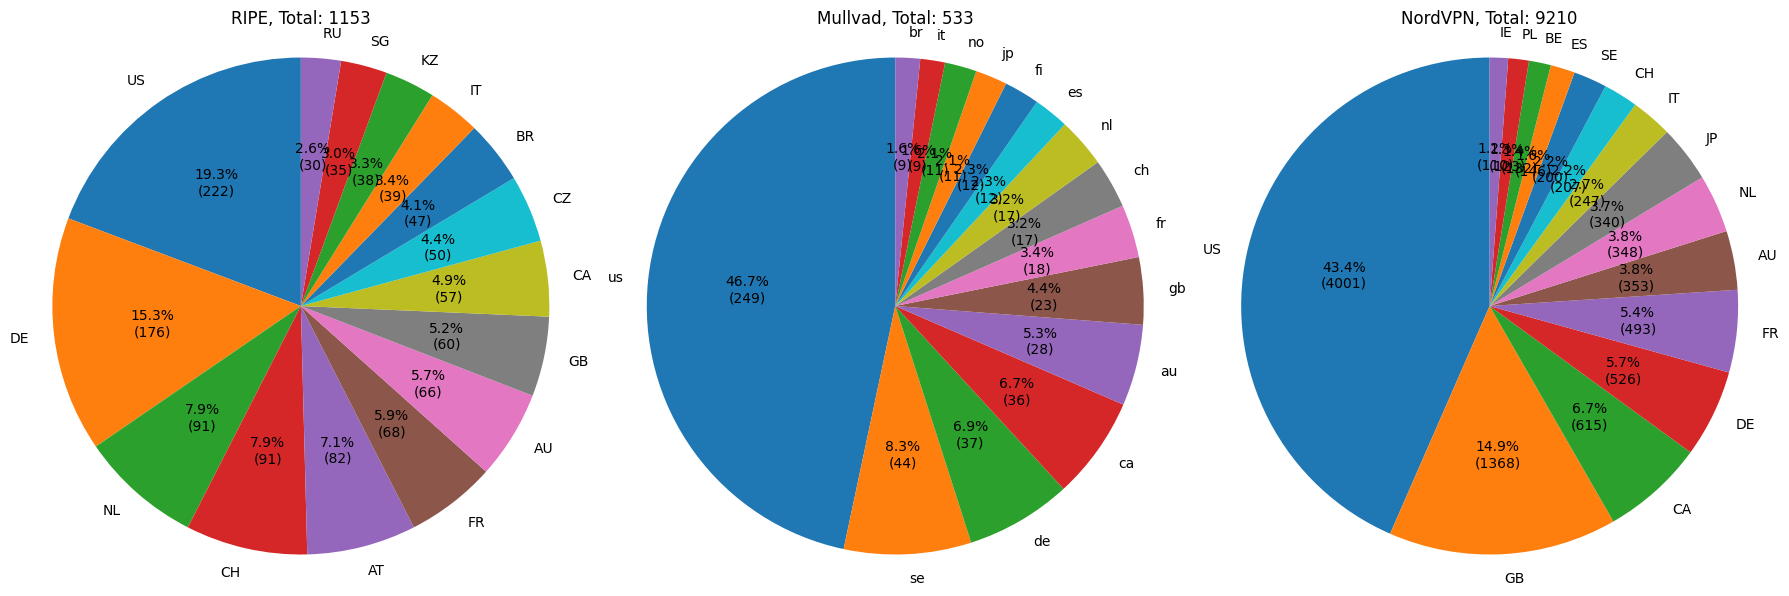

In [45]:
# Separate each origins 
origins = measurements['origin'].unique()
fig, axes = plt.subplots(1, 3, figsize=(18,6))

def cust_format(x):
    return '{:.1f}%\n({:.0f})'.format(x, origin_counts["count"].sum()*x/100)

for ax, origin in zip(axes, origins):
    origin_counts = counts[counts['origin'] == origin].copy()
    
    top = origin_counts.iloc[:15]
    other_sum = origin_counts.iloc[15:]['count'].sum()
    ax.pie(top['count'], labels=top['ground_truth'], autopct=cust_format, startangle=90)
    ax.set_title(f"{origin}, Total: {origin_counts["count"].sum()}")
    ax.axis('equal')
    

plt.tight_layout()
plt.show()

The dataset will be split into a training set, a dev set, and a test set, per Geron's own recommendations; thus holdout validation is our chosen validation technique, for now. The training set and dev set will come from our RIPE anchors. The final test set will come from our VPNs. We will go for stratified sampling on as to make sure both splits are representative of our whole dataset. 


In [46]:
from sklearn.model_selection import train_test_split

min_samples = 2

# Keep only classes with at least min_samples
grouped = measurements.groupby(measurements.origin)
traindev_set = grouped.get_group("RIPE")
# otherwise won't be able to stratify 
# see: https://github.com/davidsbatista/text-classification/issues/1
traindev_set = traindev_set[traindev_set.groupby("ground_truth")["ground_truth"].transform("size") >= min_samples]

# test size -> 0.2 means 20% 
# the stratification is essential as it means the distribution of classes is identical
train_set, dev_set = train_test_split(traindev_set, test_size=0.2, stratify=traindev_set["ground_truth"], random_state=1312)
dev_set.describe()

,id,guess,latency,hops,count
count,226.000000,0.0,226.000000,226.000000,226.0
mean,2998.146018,NaN,151.779178,14.804204,4.0
std,1109.514957,NaN,137.061961,4.024521,0.0
min,990.000000,NaN,11.991750,1.000000,4.0
25%,1976.250000,NaN,43.157063,12.500000,4.0
50%,3151.000000,NaN,102.823250,15.250000,4.0
75%,4034.000000,NaN,204.819687,18.000000,4.0
max,4651.000000,NaN,571.416000,21.500000,4.0


Now let's finish the transformation on the train set. Because our features 'latency' and 'hops' follow a non-gaussian distribution and display numerous outliers, a simple Min-Max normalisation should suffice to make sure both features are on the same scale. A Z-score normalisation would have been inappropriate directly due to the non-gaussian nature of our distribution. 

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler

pipeline = make_pipeline(
    MinMaxScaler()
)

preprocessing = ColumnTransformer([
    ("standardise", pipeline, ["latency", "hops"])
], remainder='passthrough')

prepared_train_set = preprocessing.fit_transform(train_set)
prepared_train_set